In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [71]:
df=pd.read_csv('titanic_toy.csv')

In [72]:
df.sample(5)

,Age,Fare,Family,Survived
102,21.0,77.2875,1,0
186,NaN,15.5000,1,1
403,28.0,15.8500,1,0
164,1.0,39.6875,5,0
621,42.0,52.5542,1,1


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [74]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [75]:
X = df.drop('Survived',axis=1)
y=df.Survived

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [77]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [78]:
X_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [79]:
mean_age= X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare= X_train['Fare'].median()

In [80]:
X_train['Age_median']= X_train['Age'].fillna(median_age)
X_train['Age_mean']= X_train['Age'].fillna(mean_age)

X_train['Fare_median']= X_train['Fare'].fillna(median_fare)
X_train['Fare_mean']= X_train['Fare'].fillna(mean_age)

In [81]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
800,34.0,13.0000,0,34.0,34.0,13.0000,13.0000
645,48.0,76.7292,1,48.0,48.0,76.7292,76.7292
550,17.0,110.8833,2,17.0,17.0,110.8833,110.8833
370,25.0,55.4417,1,25.0,25.0,55.4417,55.4417
190,32.0,13.0000,0,32.0,32.0,13.0000,13.0000


In [82]:
print('Original Age variance:', X_train['Age'].var())
print('Age_median variance:', X_train['Age_median'].var())
print('Age_mean variance:', X_train['Age_mean'].var())
      
print('Original Fare variance:', X_train['Fare'].var())
print('Fare_median variance:', X_train['Fare_median'].var())
print('Fare_mean variance:', X_train['Fare_mean'].var())

Original Age variance: 210.2517072477435
Age_median variance: 169.20731007048155
Age_mean variance: 168.85193366872227
Original Fare variance: 2761.0314349486343
Fare_median variance: 2637.012481677765
Fare_mean variance: 2621.6705110298376


In [83]:
#variance decreases

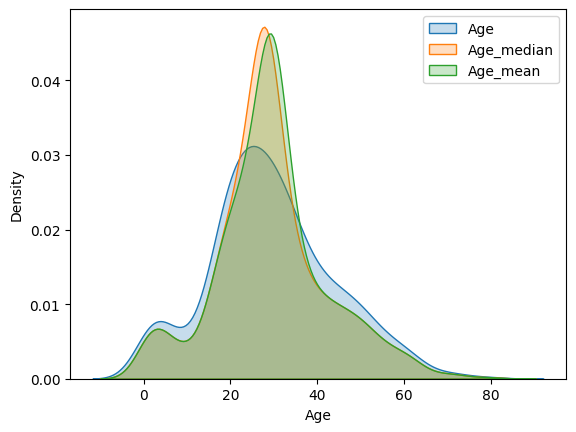

In [84]:
sns.kdeplot(X_train['Age'],fill=True, label='Age')
sns.kdeplot(X_train['Age_median'],fill=True, label='Age_median')
sns.kdeplot(X_train['Age_mean'],fill=True, label='Age_mean')
plt.legend()
plt.show()

In [85]:
# distribution has been changed. Hence, it is red fla

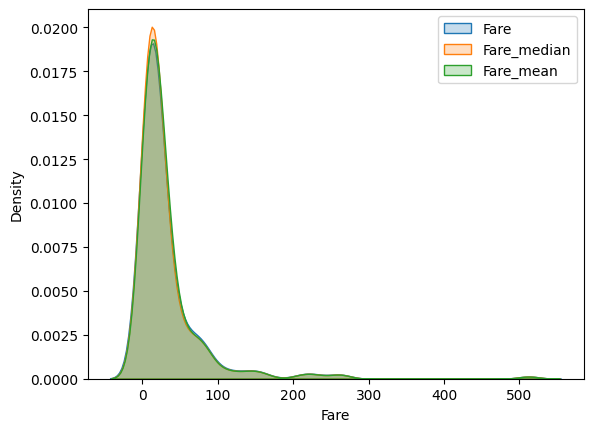

In [86]:
sns.kdeplot(X_train['Fare'],fill=True, label='Fare')
sns.kdeplot(X_train['Fare_median'],fill=True, label='Fare_median')
sns.kdeplot(X_train['Fare_mean'],fill=True, label='Fare_mean')
plt.legend()
plt.show()

In [87]:
#here no much distribution change obserced(overlaped with each other)
#green flag

In [88]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.008529
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.659866
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.538695
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.026540
Fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2623.861792
Fare_mean,71.008529,2761.031435,17.659866,60.538695,57.026540,2623.861792,2621.670511


In [89]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.087232,0.088692
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204536,0.204992
Age_median,1.000000,0.093496,-0.255307,1.000000,0.998949,0.089416,0.090894
Age_mean,1.000000,0.088151,-0.256883,0.998949,1.000000,0.084346,0.085711
Fare_median,0.087232,1.000000,0.204536,0.089416,0.084346,1.000000,0.997920
Fare_mean,0.088692,1.000000,0.204992,0.090894,0.085711,0.997920,1.000000


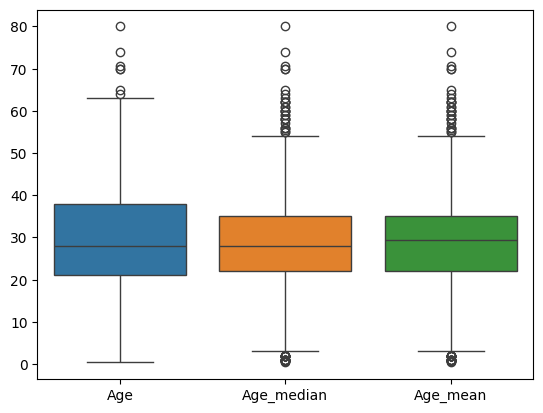

In [90]:
sns.boxplot(data= X_train[['Age','Age_median','Age_mean']])
plt.show()

In [91]:
#IQR shrinks and hence outliner increases (red flag)

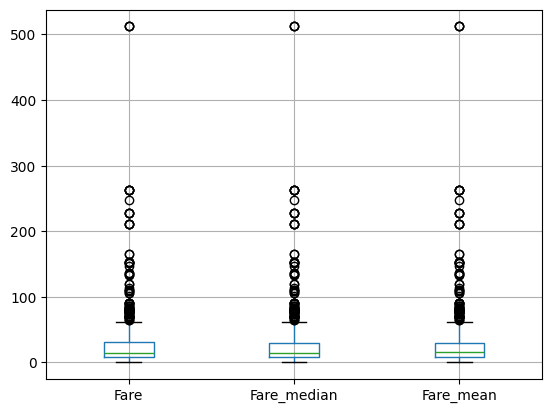

In [92]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()
plt.show()

In [93]:
# here , it is better to use Simple Imputer in Fare , but not in Age column.

#### Using Sklearn

In [103]:
X_test, X_train, y_train,  y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [104]:
impute1 = SimpleImputer(strategy='median')
impute2= SimpleImputer(strategy='mean')

In [105]:
trf= ColumnTransformer([
    ('impute1',impute1,['Age']),
    ('impute2',impute2,['Fare'])
], remainder='passthrough')

In [107]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute1', ...), ('impute2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [109]:
trf.named_transformers_['impute1'].statistics_

array([29.])

In [110]:
trf.named_transformers_['impute2'].statistics_

array([31.33115118])

In [111]:
X_train = trf.transform(X_train)
X_test= trf.transform(X_test)